# GCAP3226 Week 4 — In-class exercise (5%)

**Individual.** Three tasks + submit (Commit & Push → Moodle GitHub URL).

| Task | Do this |
|------|---------|
| **1** | Percentage change by A&E triage; largest fall / rise; triage 4+5 combined |
| **2** | Grouped bar chart: H1 2025 vs H1 2026 attendances by triage (10 bars) + numbers / percentage change |
| **3** | Short write-up: one supporting point + one gap for the A&E claim |


## Setup

Run the next cell. Data: `week4_ae_triage_h1.csv` (**H1** 2025 vs **H1** 2026 attendances by triage).

**H1** = first half of the year (usually **1 January – 30 June**).

**AI:** `Cmd+I` / `Ctrl+I` on a code cell → implement the comment prompt → **Keep**. Interpretations in your own words.


In [8]:
# Setup — run first
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "week4_ae_triage_h1.csv"
path = Path(DATA_FILE) if Path(DATA_FILE).is_file() else Path.cwd() / DATA_FILE
df = pd.read_csv(path)
print("Using:", path.resolve())
df



Using: /workspaces/GCAP3226_week4/week4_ae_triage_h1.csv


,triage,triage_name,attend_h1_2025,attend_h1_2026
0,1,Critical,13848,14541
1,2,Emergency,28554,29981
2,3,Urgent,400428,411994
3,4,Semi-urgent,489032,441974
4,5,Non-urgent,18448,14758


## Task 1 — Percentage change

**Purpose:** Measure how A&E attendances changed from H1 2025 to H1 2026 for each triage group, so you can see which groups rose or fell before judging the A&E claim in Task 3.

1. Add a column `pct_change` = `(attend_h1_2026 - attend_h1_2025) / attend_h1_2025 * 100`.
2. Show the table.
3. Print the triage with the **largest fall** and the **largest rise**.
4. Compute the percentage change for triage **4+5 combined** (sum attendances first, then apply the same formula).

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


In [9]:
# Task 1
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
# Process: Write Python code to add pct_change, display the table,
#          print largest fall and largest rise; also 4+5 combined percentage change
# Output: table + printed fall/rise + 4+5 combined
#
# YOUR CODE BELOW

df = df.copy()
df['pct_change'] = (df['attend_h1_2026'] - df['attend_h1_2025']) / df['attend_h1_2025'] * 100

print('Task 1 table with percentage change:')
print(df[['triage', 'triage_name', 'attend_h1_2025', 'attend_h1_2026', 'pct_change']].to_string(index=False))

largest_fall = df.loc[df['pct_change'].idxmin()]
largest_rise = df.loc[df['pct_change'].idxmax()]

print('\nLargest fall:')
print(f"{largest_fall['triage_name']}: {largest_fall['pct_change']:.2f}%")

print('\nLargest rise:')
print(f"{largest_rise['triage_name']}: {largest_rise['pct_change']:.2f}%")

triage_45_2025 = df[df['triage'].isin([4, 5])]['attend_h1_2025'].sum()
triage_45_2026 = df[df['triage'].isin([4, 5])]['attend_h1_2026'].sum()
triage_45_pct_change = (triage_45_2026 - triage_45_2025) / triage_45_2025 * 100

print('\nTriage 4+5 combined percentage change:')
print(f"{triage_45_pct_change:.2f}%")


Task 1 table with percentage change:
 triage triage_name  attend_h1_2025  attend_h1_2026  pct_change
      1    Critical           13848           14541    5.004333
      2   Emergency           28554           29981    4.997549
      3      Urgent          400428          411994    2.888409
      4 Semi-urgent          489032          441974   -9.622683
      5  Non-urgent           18448           14758  -20.002168

Largest fall:
Non-urgent: -20.00%

Largest rise:
Critical: 5.00%

Triage 4+5 combined percentage change:
-10.00%


In [4]:
# Task 1 note
task1_note = """
Triage 1–2 mainly rose: Critical +5.0% and Emergency +5.0%, while triage 4–5 mainly fell, with Semi-urgent -9.6% and Non-urgent -20.0%. This pattern fits the A&E claim: lower-urgency demand fell while critical/emergency care remained protected.
"""
print(task1_note)



Triage 1–2 mainly rose: Critical +5.0% and Emergency +5.0%, while triage 4–5 mainly fell, with Semi-urgent -9.6% and Non-urgent -20.0%. This pattern fits the A&E claim: lower-urgency demand fell while critical/emergency care remained protected.



## Task 2 — Grouped attendance chart + percentage-change chart

**Purpose:** Compare H1 2025 and H1 2026 attendances by triage in a grouped bar chart, and show the percentage change in a separate horizontal chart so labels stay readable and do not overlap.

1. Create a grouped bar chart with **5 triage groups** on the x-axis and **2 bars per group** (H1 2025 and H1 2026).
2. Add attendance value labels for each bar.
3. Create a separate horizontal percentage-change chart for the same triage groups.
4. Keep the figure readable with clear titles, labels, and annotation placement.

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


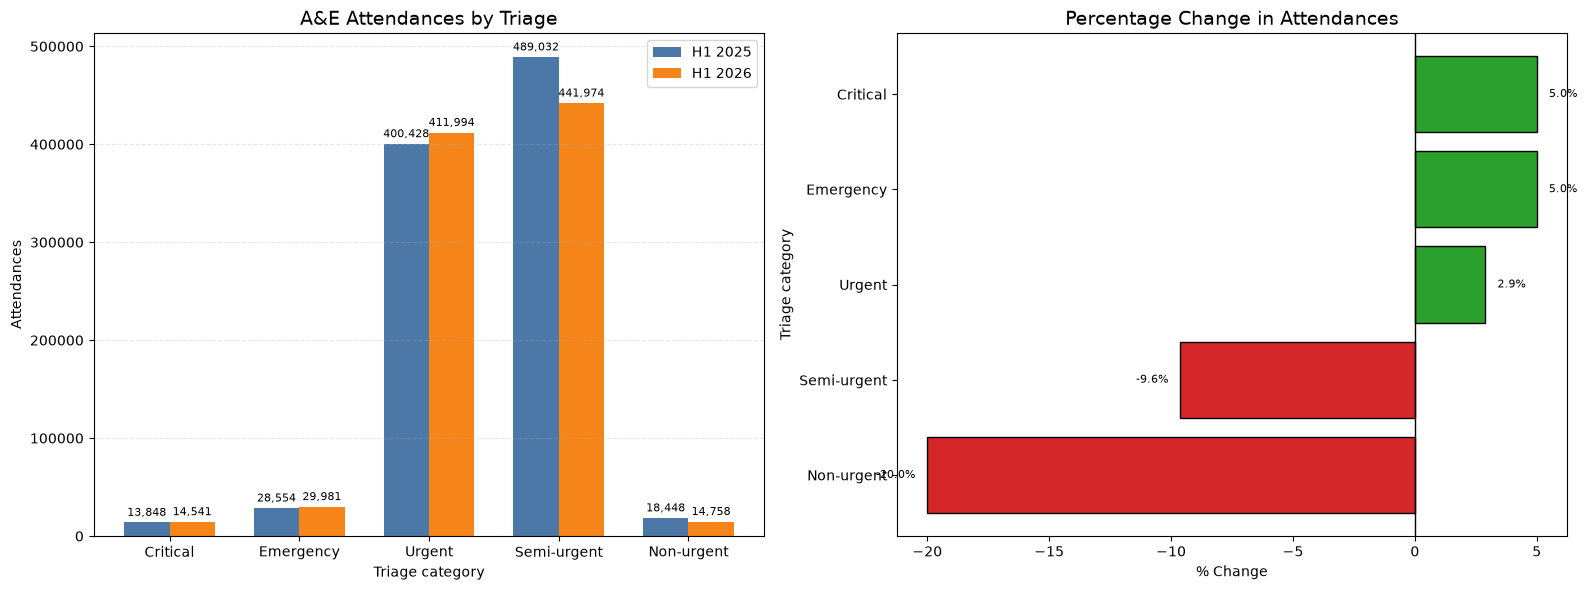

In [11]:
# Task 2
# Input: df, containing triage names, H1 2025 attendances,
#        H1 2026 attendances, and pct_change from Task 1.
# Process: Create a grouped attendance chart and a separate horizontal
#          percentage-change chart so labels do not overlap.
# Output: One figure with attendance numbers and readable percentage changes.
#
# YOUR CODE BELOW

df = df.copy()
df['pct_change'] = (df['attend_h1_2026'] - df['attend_h1_2025']) / df['attend_h1_2025'] * 100

plot_df = df[['triage', 'triage_name', 'attend_h1_2025', 'attend_h1_2026', 'pct_change']].copy()

x = range(len(plot_df))
bar_width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

bars_2025 = ax1.bar([i - bar_width/2 for i in x], plot_df['attend_h1_2025'],
                   width=bar_width, label='H1 2025', color='#4C78A8')
bars_2026 = ax1.bar([i + bar_width/2 for i in x], plot_df['attend_h1_2026'],
                   width=bar_width, label='H1 2026', color='#F58518')

ax1.set_title('A&E Attendances by Triage', fontsize=14)
ax1.set_xlabel('Triage category')
ax1.set_ylabel('Attendances')
ax1.set_xticks(list(x))
ax1.set_xticklabels(plot_df['triage_name'], rotation=0)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Add attendance labels
for bars in [bars_2025, bars_2026]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 4000,
                 f'{int(height):,}', ha='center', va='bottom', fontsize=8)

# Separate horizontal chart for percentage change so labels remain readable
pct_colors = ['tab:green' if v >= 0 else 'tab:red' for v in plot_df['pct_change']]
barh = ax2.barh(plot_df['triage_name'], plot_df['pct_change'], color=pct_colors, edgecolor='black')
ax2.axvline(0, color='black', linewidth=1)
ax2.set_title('Percentage Change in Attendances', fontsize=14)
ax2.set_xlabel('% Change')
ax2.set_ylabel('Triage category')
ax2.invert_yaxis()

for container, value in zip(barh, plot_df['pct_change']):
    x_pos = value + (0.5 if value >= 0 else -0.5)
    ha = 'left' if value >= 0 else 'right'
    ax2.text(x_pos, container.get_y() + container.get_height() / 2, f'{value:.1f}%',
             va='center', ha=ha, fontsize=8, color='black')

plt.tight_layout()
plt.show()


## Task 3 — Write-up

**Claim:** After fee reform, A&E improved — lower-urgency attendances fell; critical/emergency care stayed protected; urgent care became more efficient.

You may also cite: triage III within 30 min **81.4 → 88.5** (percentage); mean wait **23 → 20** min.

**3a** — Write **one supporting point** (cite a number) and **one gap** in the evidence.

**3b** — 2–4 sentences: how well is the claim supported by the published evidence (your table / chart, and any figures cited above)?


In [5]:
# Task 3
task3a = """
3a SUPPORT (1 point, cite a number):
The pattern is consistent with the claim: triage 4+5 combined fell by 10.0% from 507,480 to 456,732 attendances, while triage 1–2 rose by about 5.0% (from 42,402 to 44,522), suggesting lower-urgency demand fell while critical/emergency care stayed protected.

3a GAP (1 point):
The table shows a pattern, but it does not prove where lower-urgency patients went or whether they were diverted to other settings; without that evidence, the claim of reduced misuse and improved efficiency remains partly inferred rather than fully demonstrated.
"""

task3b = """
3b:
The evidence supports the claim only to a limited extent. The triage pattern is consistent with the reform story: triage 4+5 combined fell by 10.0%, while triage 1–2 rose by about 5.0%, which suggests lower-urgency demand reduced without harming critical/emergency care. A stronger support point is that triage III within 30 minutes improved from 81.4% to 88.5% and mean wait fell from 23 to 20 minutes, which supports greater A&E efficiency. However, the published evidence still has a clear gap: it does not show whether lower-urgency patients were treated elsewhere, whether unmet need rose, or whether the reduced volumes were truly caused by the fee reform rather than other factors.
"""

print(task3a)
print("---")
print(task3b)



3a SUPPORT (1 point, cite a number):
The pattern is consistent with the claim: triage 4+5 combined fell by 10.0% from 507,480 to 456,732 attendances, while triage 1–2 rose by about 5.0% (from 42,402 to 44,522), suggesting lower-urgency demand fell while critical/emergency care stayed protected.

3a GAP (1 point):
The table shows a pattern, but it does not prove where lower-urgency patients went or whether they were diverted to other settings; without that evidence, the claim of reduced misuse and improved efficiency remains partly inferred rather than fully demonstrated.

---

3b:
The evidence supports the claim only to a limited extent. The triage pattern is consistent with the reform story: triage 4+5 combined fell by 10.0%, while triage 1–2 rose by about 5.0%, which suggests lower-urgency demand reduced without harming critical/emergency care. A stronger support point is that triage III within 30 minutes improved from 81.4% to 88.5% and mean wait fell from 23 to 20 minutes, which s

## Submit

1. Save → Source Control → **Commit & Push**  
2. Moodle: paste your **GitHub URL**
